# Key Independent Variables

We found key independent variables in [02_correlation.ipynb](02_correlation.ipynb).
This notebook focuses on those variables (socioeconomic factors) that show strong relationships with our target variable, Mental Health Distress.

We dive deeper into the distributions of these selected variables to understand their data characteristics, ranges, and potential skewness across counties.

In [1]:
# data loading code is in load_data.py
from load_data import load_places, load_acs_profiles
# get the places data
df_places = load_places()
# get the ACS profiles data (This takes a while to load because it loads multiple files and merges them)
df_acs_profiles = load_acs_profiles()

## 1. Variable Definition & Preparation

Before analyzing the data, we map the raw American Community Survey (ACS) profile codes to clear, interpretable labels for the five selected independent variables:

- **Bachelor's Degree**: Percentage of population with a bachelor's degree or higher
- **Private Health Insurance**: Percentage of population with private health insurance
- **Disability**: Percentage of population with a disability
- **Employment**: Employment rate
- **Poverty**: Poverty rate

In [2]:
variables = {
    'DP02_0065PE': "Bachelor's Degree",
    'DP03_0097PE': "Private Health Insurance",
    'DP02_0076PE': "With a Disability",
    'DP03_0004PE': "Employed",
    'DP03_0128PE': "Below Poverty Level",
}

In [3]:
df_places = df_places[['StateAbbr', 'StateDesc', 'CountyName', 'CountyFIPS', 'MHLTH_AdjPrev']]

In [4]:
df_acs_profiles = df_acs_profiles[['CountyFIPS'] + list(variables.keys())]

## 2. Distribution of Independent Variables

Let's examine the distribution of each independent variable across all counties using histograms.
This helps us identify whether the data is normally distributed, heavily skewed, or contains notable outliers.

C:\Users\user\AppData\Roaming\Python\Python312\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.5.2)
  from scipy.stats import gaussian_kde


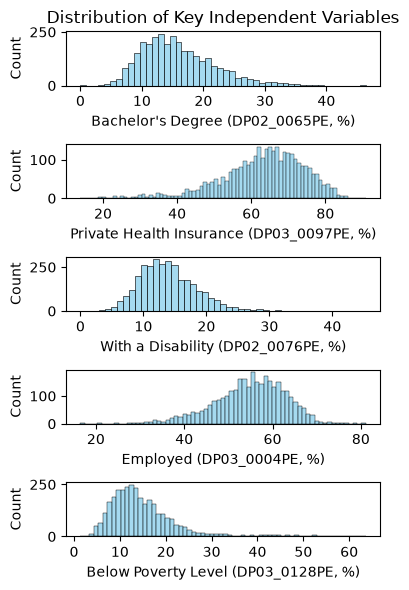

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt


fig, axes = plt.subplots(len(variables), 1, figsize=(4, 6), sharex=False)

import math


for i, (ax, var) in enumerate(zip(axes, variables)):
    if i == 0:
        ax.set_title("Distribution of Key Independent Variables")
    bins = math.ceil(df_acs_profiles[var].max()) - math.floor(df_acs_profiles[var].min()) + 1
    sns.histplot(df_acs_profiles[var], bins=bins, ax=ax, color='skyblue')
    # ax.set_title(f"Distribution of {name_map[var]} ({var})")
    ax.set_xlabel(f"{variables[var]} ({var}, %)")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()


### Key Insights from the Distribution:

* **Skewness and Range:** Some variables (such as poverty or higher education rates) may exhibit right- or left-skewness across counties, reflecting regional socioeconomic disparities.

## 3. Variable Interactions

To better understand how these socioeconomic factors relate to one another,
we next explore their interactions with Spearman correlation.

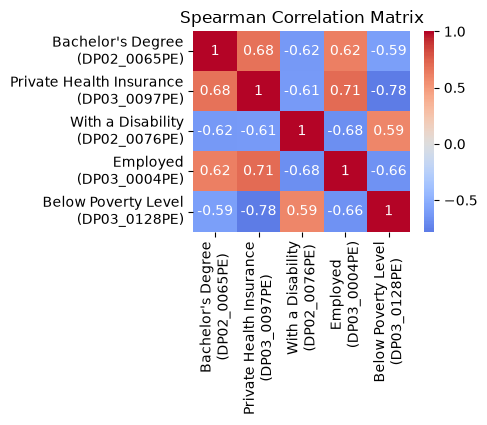

In [6]:
corr_matrix = df_acs_profiles[variables.keys()].corr(method='spearman')

labels = {var: variables.get(var, var) + f"\n({var})" for var in variables.keys()}
corr_matrix.rename(columns=labels, index=labels, inplace=True)

# plot the correlation matrix
plt.figure(figsize=(3.5, 2.6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Spearman Correlation Matrix')
plt.xlabel("")
plt.ylabel("")
plt.show()

The correlation matrix reveals clear socioeconomic patterns.
It reveals strong relationships across all key variable pairs.

## 4. 2D Distribution

Draw and see 2D distribution of the key independent variables and the dependent variable.
We can verify that our previously calculated correlations are robust and not driven by outliers or non-linear anomalies.
We use scatter plot and red linear regression line (OLS).

In [7]:
import pandas as pd
df_merged = pd.merge(df_places, df_acs_profiles, on='CountyFIPS', how='inner')

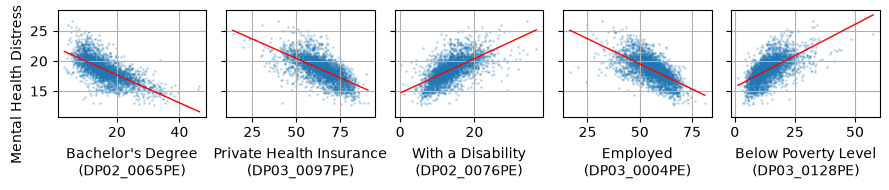

In [8]:
import numpy as np

fig, axes = plt.subplots(
    1, 5,
    figsize=(9, 2),
    sharey=True
)

for i, var in enumerate(variables):
    ax = axes[i]
    df = df_merged[[var, 'MHLTH_AdjPrev']].dropna()
    ax.scatter(df[var], df['MHLTH_AdjPrev'], alpha=0.2, s=1)
    ax.set_xlabel(variables[var] + '\n(' + var + ')')
    if i == 0:
        ax.set_ylabel('Mental Health Distress', y=0.3)

    # OLS
    # The data contains a few thousand records,
    # so OLS is not so different from RLM.
    m, b = np.polyfit(df[var], df['MHLTH_AdjPrev'], 1)
    x_line = np.linspace(df[var].min(), df[var].max(), 100)
    ax.plot(x_line, m * x_line + b, color='red', linewidth=1)
    ax.grid(True)

    if i > 0:
        ax.tick_params(axis='y', labelleft=False)

plt.tight_layout()
plt.show()


The scatter plots show that the data points for each key variable are in a clear, consistent trend without severe anomalies or unusual distributions.
This visually confirms that the correlations are robust and reflect genuine patterns.